<a href="https://colab.research.google.com/github/Pranayshukla0610/Python_Projects/blob/main/Naive_Bayes_On_Fake_News_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

with zipfile.ZipFile("/content/archive.zip") as zip_ref:
  zip_ref.extractall()

In [ ]:
import pandas as pd
import numpy as np

fake = pd.read_csv("/content/Fake.csv")
real = pd.read_csv("/content/True.csv")

In [ ]:
fake["label"] = 0
real["label"] = 1

df = pd.concat([fake,real])

df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
df = df[['title','text','subject','label']]
df.dropna(inplace=True)

df['content'] = df['title'] + " " + df['text']

df.head()

,title,text,subject,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,0,Pope Francis Just Called Out Donald Trump Dur...


In [ ]:
df['text_length'] = df['content'].apply(len)

In [ ]:
df.head()

,title,text,subject,label,content,text_length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,0,Donald Trump Sends Out Embarrassing New Year’...,2973
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,0,Drunk Bragging Trump Staffer Started Russian ...,1968
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,0,Sheriff David Clarke Becomes An Internet Joke...,3688
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,0,Trump Is So Obsessed He Even Has Obama’s Name...,2853
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,0,Pope Francis Just Called Out Donald Trump Dur...,2417


In [ ]:
df['word_count'] = df['content'].apply(lambda x:len(x.split()))

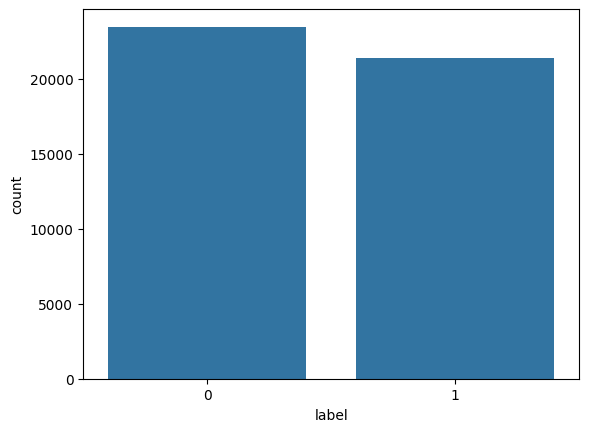

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label',data=df)
plt.show()

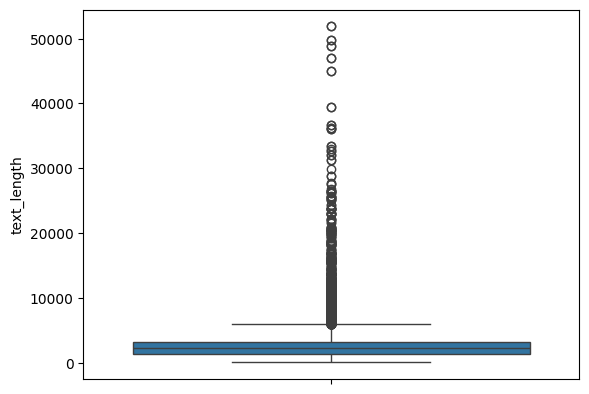

In [ ]:
sns.boxplot(df['text_length'])
plt.show()

In [ ]:
Q1 = df["text_length"].quantile(0.25)
Q3 = df["text_length"].quantile(0.75)

IQR = Q3 - Q1

df = df[(df["text_length"] >= Q1 - 1.5*IQR) &
        (df["text_length"] <= Q3 + 1.5*IQR)]

In [ ]:
df.head()

,title,text,subject,label,content,text_length,word_count
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,0,Donald Trump Sends Out Embarrassing New Year’...,2973,507
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,0,Drunk Bragging Trump Staffer Started Russian ...,1968,313
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,0,Sheriff David Clarke Becomes An Internet Joke...,3688,595
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,0,Trump Is So Obsessed He Even Has Obama’s Name...,2853,458
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,0,Pope Francis Just Called Out Donald Trump Dur...,2417,431


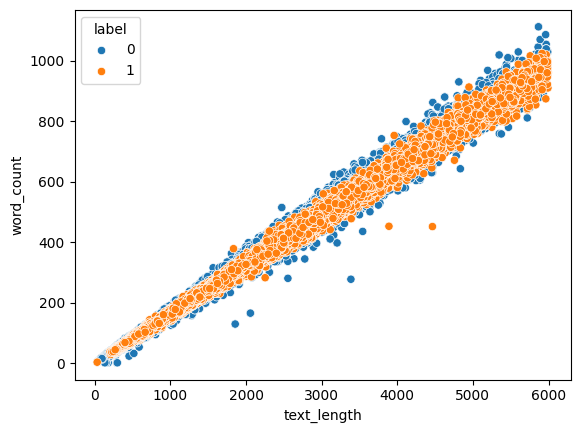

In [ ]:
sns.scatterplot(
    x=df["text_length"],
    y=df["word_count"],
    hue=df['label']
)
plt.show()

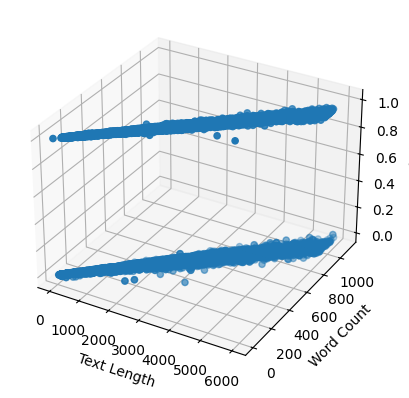

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["text_length"],
    df["word_count"],
    df["label"]
)

ax.set_xlabel("Text Length")
ax.set_ylabel("Word Count")
ax.set_zlabel("Label")

plt.show()

In [ ]:
import nltk

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    text = text.lower()
    words = text.split()

    words = [ps.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
df["clean_content"] = df["content"].apply(clean_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_content"]).toarray()

In [ ]:
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [ ]:
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()
bnb.fit(X_train,y_train)

BernoulliNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9299791328541618

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[4201,  285],
       [ 319, 3821]])

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4486
           1       0.93      0.92      0.93      4140

    accuracy                           0.93      8626
   macro avg       0.93      0.93      0.93      8626
weighted avg       0.93      0.93      0.93      8626



In [ ]:
y_pred_gnb = gnb.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_gnb)

0.9231393461627637

In [ ]:
confusion_matrix(y_test,y_pred_gnb)

array([[4293,  193],
       [ 470, 3670]])

In [ ]:
print(classification_report(y_test,y_pred_gnb))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      4486
           1       0.95      0.89      0.92      4140

    accuracy                           0.92      8626
   macro avg       0.93      0.92      0.92      8626
weighted avg       0.92      0.92      0.92      8626



In [ ]:
y_pred_bnb = bnb.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_bnb)

0.9651054950150707

In [ ]:
confusion_matrix(y_test,y_pred_bnb)

array([[4316,  170],
       [ 131, 4009]])

In [ ]:
print(classification_report(y_test,y_pred_bnb))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      4486
           1       0.96      0.97      0.96      4140

    accuracy                           0.97      8626
   macro avg       0.96      0.97      0.97      8626
weighted avg       0.97      0.97      0.97      8626

